# Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown
from sklearn.preprocessing import LabelEncoder

In [7]:
# Load datasets
bioimpedance_df = pd.read_excel('Bioimpedance_Synthetic.xlsx')
health_exam_df = pd.read_excel('Health_Exam_Synthetic.xlsx')
hrv_df = pd.read_excel('HRV_Synthetic.xlsx')

# Step 1: Data Integration & Preprocessing 

In [8]:
# Merge datasets
merged_df = bioimpedance_df.merge(health_exam_df, on='USUBJID').merge(hrv_df, on='USUBJID')

# Calculate AGE
merged_df['AGE'] = pd.to_datetime(merged_df['DVDTC']).dt.year - pd.to_datetime(merged_df['BIRTHDTC']).dt.year

# Drop date columns
merged_df.drop(columns=['BIRTHDTC', 'DVDTC'], inplace=True)

# Encode categorical features
categorical_cols = merged_df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('USUBJID')


from sklearn.preprocessing import LabelEncoder

# Label encode all categorical columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])
    label_encoders[col] = le 


In [9]:
print(merged_df['SEX'].unique())

male_df = merged_df[merged_df['SEX'] == 0].copy()
female_df = merged_df[merged_df['SEX'] == 1].copy()

[1 0]


In [10]:
#final_df = merged_df
#final_df = male_df
final_df = female_df


final_df = final_df.drop(columns=['SEX'])


In [11]:
final_df.columns

Index(['USUBJID', 'TBW', 'ICW', 'ECW', 'PROT', 'MINERAL', 'SLM', 'FFM', 'SMM',
       'PBF', 'SLRA–SLLL', 'SWRA–SWLL', 'ICWRA–ICWLL', 'ECWRA–ECWLL', 'ECWR',
       'ECWRRA–ECWRLL', 'FATRA–FATLL', 'BMR', 'ABFR', 'VFA', 'BCM', 'BRMC',
       'BMC', 'BHYDR', 'FFMI', 'FMI', 'CHMC', 'ABDMC', 'RAMC', 'LAMC', 'RLMC',
       'LLMC', 'CHSTFATTHICK', 'ABDMFATTHICK', 'RAFATTHICK', 'LAFATTHICK',
       'RLFATTHICK', 'LLFATTHICK', 'SITEID', 'MSYN', 'HEIGHT', 'WEIGHT', 'BMI',
       'SYSBP', 'DIABP', 'PULSE', 'SMOKECNF', 'ALCOHOLYN', 'MH_HL', 'MH_HTN',
       'MH_DM', 'CM_HL', 'CM_HTN', 'CM_DM', 'cold', 'heat', 'chcat',
       'PSSTOTAL', 'PSQITOTAL', 'CREAT', 'GFRE', 'HGB', 'GLUC', 'AST', 'ALT',
       'GGT', 'WAISTCIR', 'HIPCIR', 'VLF', 'LF', 'HF', 'TP', 'LFNM', 'HFNM',
       'HR', 'HRVINDEX', 'SDNN', 'AGE'],
      dtype='object')

# Step 2: Exploratory Data Analysis (EDA)

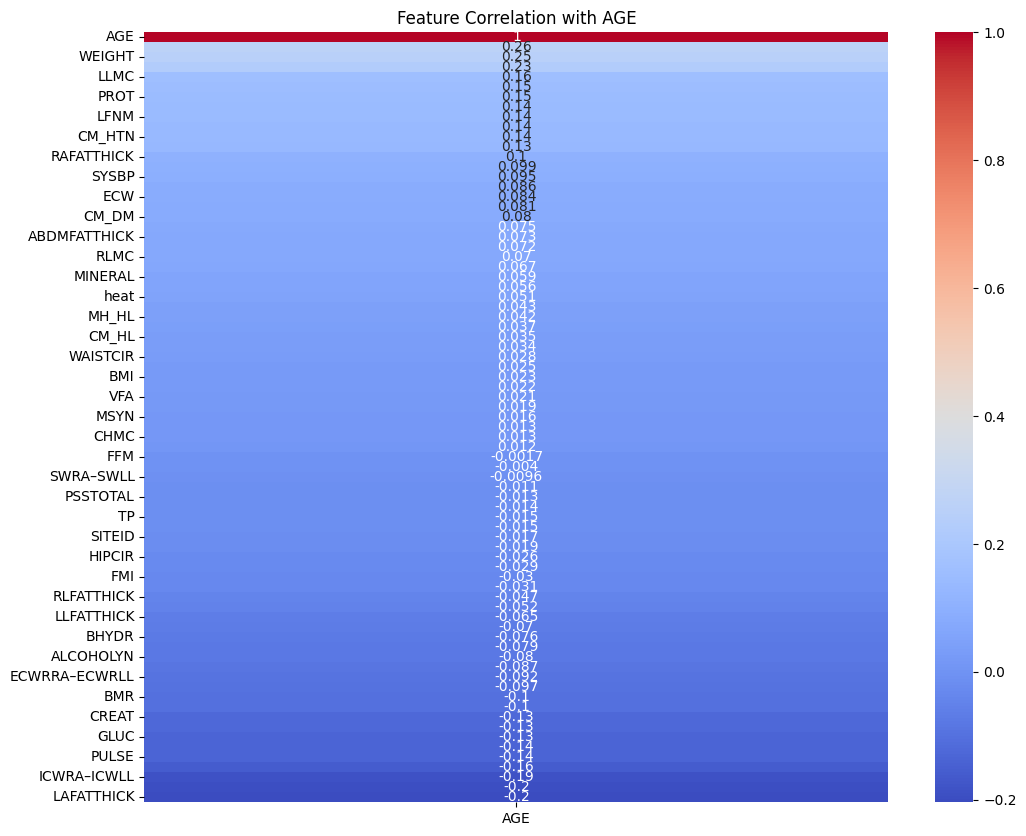

In [12]:
# Compute correlation matrix only on numeric columns
corr_matrix = final_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['AGE']].sort_values(by='AGE', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with AGE')
plt.show()

# Step 3: Feature Selection (with Dynamic Explanation)

## Feature Description

In [13]:
feature_metadata = {

    # === Bioimpedance Features ===
    'TBW': 'Total Body Water — decreases with aging due to muscle and hydration loss.',
    'ICW': 'Intracellular Water — decreases with aging due to muscle loss.',
    'ECW': 'Extracellular Water — increases with aging due to tissue composition changes.',
    'PROT': 'Protein Mass — reflects nutritional status and lean body mass.',
    'MINERAL': 'Mineral Content — reflects bone density and mineral status, may decline with age.',
    'SLM': 'Soft Lean Mass — lean mass excluding bone, declines with aging.',
    'FFM': 'Fat-Free Mass — protective against frailty, declines with aging.',
    'SMM': 'Skeletal Muscle Mass — declines with aging, marker of sarcopenia.',
    'PBF': 'Percent Body Fat — increases with aging, linked to metabolic risk.',
    'SLRA–SLLL': 'Segmental Lean Ratio — reflects muscle distribution.',
    'SWRA–SWLL': 'Segmental Water Ratio — indicates fluid distribution.',
    'ICWRA–ICWLL': 'Intracellular Water Ratio — marker of hydration and cell health.',
    'ECWRA–ECWLL': 'Extracellular Water Ratio — reflects tissue hydration and aging.',
    'ECWR': 'ECW to Total Body Water Ratio — increases with aging.',
    'ECWRRA–ECWRLL': 'Segmental ECW Ratio — reflects fluid balance.',
    'FATRA–FATLL': 'Fat Ratio — indicates regional fat distribution.',
    'BMR': 'Basal Metabolic Rate — declines with age due to muscle loss.',
    'ABFR': 'Abdominal Fat Ratio — linked to visceral fat and metabolic aging.',
    'VFA': 'Visceral Fat Area — increases with aging, risk factor for metabolic disease.',
    'BCM': 'Body Cell Mass — declines with age due to muscle and lean mass loss.',
    'BRMC': 'Body Right Muscle Content — relates to skeletal muscle status.',
    'BMC': 'Bone Mineral Content — reflects bone density, declines with aging.',
    'BHYDR': 'Body Hydration — decreases with age due to muscle loss and dehydration.',
    'FFMI': 'Fat-Free Mass Index — protective against aging effects.',
    'FMI': 'Fat Mass Index — increases with aging.',
    'CHMC': 'Chest Muscle Content — muscle mass in chest region.',
    'ABDMC': 'Abdominal Muscle Content — core muscle mass.',
    'RAMC': 'Right Arm Muscle Content — muscle mass in right arm.',
    'LAMC': 'Left Arm Muscle Content — muscle mass in left arm.',
    'RLMC': 'Right Leg Muscle Content — muscle mass in right leg.',
    'LLMC': 'Left Leg Muscle Content — muscle mass in left leg.',
    'CHSTFATTHICK': 'Chest Fat Thickness — regional fat indicator.',
    'ABDMFATTHICK': 'Abdominal Fat Thickness — marker of visceral fat.',
    'RAFATTHICK': 'Right Arm Fat Thickness — regional fat indicator.',
    'LAFATTHICK': 'Left Arm Fat Thickness — regional fat indicator.',
    'RLFATTHICK': 'Right Leg Fat Thickness — regional fat indicator.',
    'LLFATTHICK': 'Left Leg Fat Thickness — regional fat indicator.',

    # === Health Exam / Clinical Features ===
    'SITEID': 'Study Site Identifier — administrative variable.',
    'SEX': 'Biological Sex — influences body composition and aging patterns.',
    'MSYN': 'Metabolic Syndrome Status — presence of metabolic risk factors.',
    'HEIGHT': 'Body Height — anthropometric variable.',
    'WEIGHT': 'Body Weight — general health indicator.',
    'BMI': 'Body Mass Index — linked to obesity and metabolic risk.',
    'SYSBP': 'Systolic Blood Pressure — increases with vascular aging.',
    'DIABP': 'Diastolic Blood Pressure — affected by vascular changes with age.',
    'PULSE': 'Pulse Rate — cardiovascular fitness indicator.',
    'SMOKECNF': 'Smoking Status — lifestyle factor influencing aging.',
    'ALCOHOLYN': 'Alcohol Consumption — lifestyle factor influencing aging.',
    'MH_HL': 'Medical History of Hyperlipidemia — cardiovascular risk marker.',
    'MH_HTN': 'Medical History of Hypertension — age-related cardiovascular risk.',
    'MH_DM': 'Medical History of Diabetes — metabolic disease linked to aging.',
    'CM_HL': 'Current Medication for Hyperlipidemia — treatment for cardiovascular risk.',
    'CM_HTN': 'Current Medication for Hypertension — treatment for blood pressure control.',
    'CM_DM': 'Current Medication for Diabetes — treatment for metabolic disease.',
    'cold': 'Cold Sensitivity — subjective symptom.',
    'heat': 'Heat Sensitivity — subjective symptom.',
    'chcat': 'Menopausal Status or Category — related to hormonal aging.',
    'PSSTOTAL': 'PSS Total Score — perceived stress score.',
    'PSQITOTAL': 'PSQI Total Score — sleep quality score.',
    'CREAT': 'Creatinine — kidney function marker.',
    'GFRE': 'Glomerular Filtration Rate Estimate — kidney function marker.',
    'HGB': 'Hemoglobin — nutritional and health marker.',
    'GLUC': 'Blood Glucose — linked to aging and metabolic disease.',
    'AST': 'Liver Enzyme — may reflect liver function and metabolic status.',
    'ALT': 'Liver Enzyme — liver function marker.',
    'GGT': 'Gamma-Glutamyl Transferase — oxidative stress and liver marker.',
    'WAISTCIR': 'Waist Circumference — visceral fat indicator.',
    'HIPCIR': 'Hip Circumference — body composition indicator.',

    # === HRV Features ===
    'VLF': 'Very Low Frequency Power — reflects thermoregulation and hormonal activity.',
    'LF': 'Low Frequency Power — linked to autonomic balance.',
    'HF': 'High Frequency Power — reflects parasympathetic nervous system activity.',
    'TP': 'Total Power of HRV — overall autonomic nervous system activity.',
    'LFNM': 'Low Frequency Normalized Units — autonomic balance.',
    'HFNM': 'High Frequency Normalized Units — parasympathetic activity.',
    'HR': 'Heart Rate — cardiovascular fitness marker.',
    'HRVINDEX': 'HRV Index — overall heart rate variability.',
    'SDNN': 'Standard Deviation of NN intervals — general HRV marker.',

    # === Outcome ===
    'AGE': 'Chronological Age — target variable for modeling.',

    # === Identifier ===
    'USUBJID': 'Unique Subject Identifier — not used as model input.'
}




def generate_detailed_feature_explanation(selected_features, corr_matrix, feature_metadata):
    explanation_text = "## Detailed Feature Explanation for Selected Features\n\n"

    for feature in selected_features:
        # Get correlation
        try:
            correlation = corr_matrix['AGE'][feature]
        except:
            correlation = None

        # Get biological meaning
        if feature in feature_metadata:
            meaning = feature_metadata[feature]
        else:
            meaning = "[Unknown — needs expert interpretation]"

        # Interpret correlation strength and direction
        if correlation is not None:
            abs_corr = abs(correlation)
            if abs_corr >= 0.5:
                strength = "strong"
            elif abs_corr >= 0.3:
                strength = "moderate"
            elif abs_corr >= 0.1:
                strength = "weak"
            else:
                strength = "very weak"

            if correlation > 0:
                direction = f"Higher {feature} is associated with **older** AGE."
            elif correlation < 0:
                direction = f"Higher {feature} is associated with **younger** AGE."
            else:
                direction = "No correlation with AGE."
        else:
            strength = "unknown"
            direction = "Correlation could not be computed."

        explanation_text += f"### {feature}\n\n"
        if correlation is not None:
            explanation_text += f"- **Correlation with AGE:** {correlation:.2f} ({strength} correlation)\n\n"
        else:
            explanation_text += "- **Correlation with AGE:** Not available.\n\n"

        explanation_text += f"- **Biological meaning:** {meaning}\n\n"

        explanation_text += f"- **Interpretation:** In this dataset, {direction} This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.\n\n"
        explanation_text += "---\n\n"

    from IPython.display import display, Markdown
    display(Markdown(explanation_text))




# Helper function to explain top N features from any method in scoreboard_df_sorted

def explain_top_features_from_method(method_name, top_n=10):

    print(f"\n=== Generating Explanation for Top {top_n} Features from Method: {method_name} ===\n")
    
    df_method = scoreboard_df_sorted[scoreboard_df_sorted['Method'] == method_name]
    
    if df_method.empty:
        print(f"[Warning] No features found for method: {method_name}")
        return
    
    top_features = df_method.head(top_n)['Feature'].tolist()
    
    print(f"Features selected for explanation: {top_features}\n")
    
    merged_numeric = final_df.select_dtypes(include=[np.number])
    
    generate_detailed_feature_explanation(top_features, merged_numeric.corr(), feature_metadata)




## Feature Selection Methods

Feature Selection Methods Cheat-Sheet

| Method                  | Best For                   | Pros                               | Cons                               | Use in our pipeline? |
|-------------------------|----------------------------|------------------------------------|------------------------------------|---------------------|
| **Correlation Filtering**   | Quick linear screening     | Very fast, intuitive                | Only linear, ignores interactions   | Yes, as first filter  |
| **LASSO**                   | Sparse linear models       | Automatic feature selection, simple | Biased for correlated features      |  Yes, very important   |
| **RFE with RandomForest**   | Tree-based models          | Works well for RF/GBM, interactions  | Slow, binary selection only         | Yes                   |
| **VIF**                     | Redundancy detection       | Helps avoid multicollinearity       | Not an importance score             |  Use for cleaning      |
| **Boruta**                  | All-relevant selection     | Very robust, statistical testing    | Slow, binary selection              |  Yes, very important   |
| **f_regression**            | Linear regression          | Simple, interpretable               | Only linear                         |  Good as baseline      |
| **chi2**                    | Categorical/count data     | Fast, interpretable                 | Only for non-negative features      |  Use carefully         |
| **f_classif**               | Categorical + continuous   | Good for detecting group differences| Linear only                         |  Good for screening    |
| **Wrapper_KNN**             | Non-linear relations       | Captures complex patterns           | Slow, no score, binary selection    |  Optional              |
| **Wrapper_LR**              | Linear regression          | Captures combinations               | Slow, no score, biased for linear   |  Yes                   |
| **Wrapper_RF**              | Tree models                | Captures non-linear interactions    | Slow, binary                        |  Yes                   |
| **PermutationImportance**   | Model-agnostic importance  | Very powerful, captures everything  | Computationally expensive 

!pip install boruta
!pip install eli5

In [ ]:


import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression, f_classif, chi2
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from boruta import BorutaPy
import eli5
from eli5.sklearn import PermutationImportance
from tqdm import tqdm

# Prepare data
X = final_df.drop(columns=['AGE', 'USUBJID'])
y = final_df['AGE']
X = X.select_dtypes(include=[np.number])
X_scaled = MinMaxScaler().fit_transform(X)

#_scaled = X # Non Normilazation


# Initialize result list
results = []

# --- Correlation filtering ---
print("Running Correlation filtering...")

# FIX: select only numeric columns
merged_numeric = final_df.select_dtypes(include=[np.number])
correlations = merged_numeric.corr()['AGE'].drop('AGE')
correlation_scores = correlations.abs()
for feature, score in tqdm(correlation_scores.items(), desc='Correlation'):
    results.append(['Correlation', feature, score])

# --- LASSO Regression ---
print("Running LASSO Regression...")
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X, y)
lasso_coef = lasso.coef_
for feature, coef in tqdm(zip(X.columns, lasso_coef), total=len(X.columns), desc='LASSO'):
    results.append(['LassoCV', feature, abs(coef)])

# --- Recursive Feature Elimination (RFE) with RandomForestRegressor ---
print("Running RFE...")
rf_rfe = RandomForestRegressor(random_state=42)
rfe_model = RFE(estimator=rf_rfe, n_features_to_select=10, step=1)
rfe_model.fit(X, y)
selected_rfe = X.columns[rfe_model.support_].tolist()
for feature in tqdm(X.columns, desc='RFE_RF'):
    score = 1.0 if feature in selected_rfe else 0.0
    results.append(['RFE_RF', feature, score])

# --- VIF ---
print("Running VIF...")
X_vif = sm.add_constant(X)
vif_scores = [variance_inflation_factor(X_vif.values, i) for i in tqdm(range(X_vif.shape[1]), desc='VIF')]
for feature, vif_score in zip(X_vif.columns, vif_scores):
    if feature != 'const':
        results.append(['VIF', feature, vif_score])

# --- Boruta ---
print("Running Boruta...")
X_array = X.values
y_array = y.values
rf_boruta = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=42)
boruta_selector = BorutaPy(estimator=rf_boruta, n_estimators='auto', max_iter=100, random_state=42)
boruta_selector.fit(X_array, y_array)
selected_boruta = X.columns[boruta_selector.support_].tolist()
for feature in tqdm(X.columns, desc='Boruta'):
    score = 1.0 if feature in selected_boruta else 0.0
    results.append(['Boruta', feature, score])

# --- Filter: f_regression ---
print("Running f_regression...")
selector_freg = SelectKBest(score_func=f_regression, k='all')
selector_freg.fit(X, y)
freg_scores = selector_freg.scores_
for feature, score in tqdm(zip(X.columns, freg_scores), total=len(X.columns), desc='f_regression'):
    results.append(['f_regression', feature, score])

# --- Filter: chi2 ---
print("Running chi2...")
selector_chi2 = SelectKBest(score_func=chi2, k='all')
selector_chi2.fit(X_scaled, y)
chi2_scores = selector_chi2.scores_
for feature, score in tqdm(zip(X.columns, chi2_scores), total=len(X.columns), desc='chi2'):
    results.append(['chi2', feature, score])

# --- Filter: f_classif ---
print("Running f_classif...")
selector_fclassif = SelectKBest(score_func=f_classif, k='all')
selector_fclassif.fit(X, y)
fclassif_scores = selector_fclassif.scores_
for feature, score in tqdm(zip(X.columns, fclassif_scores), total=len(X.columns), desc='f_classif'):
    results.append(['f_classif', feature, score])

# --- Wrapper: KNN ---
print("Running Wrapper KNN...")
knn = KNeighborsClassifier(n_neighbors=3)
sfs_knn = SequentialFeatureSelector(knn, n_features_to_select=10, direction='forward')
sfs_knn.fit(X, y > y.median())
selected_knn = X.columns[sfs_knn.get_support()].tolist()
for feature in tqdm(X.columns, desc='Wrapper_KNN'):
    score = 1.0 if feature in selected_knn else 0.0
    results.append(['Wrapper_KNN', feature, score])

# --- Wrapper: Linear Regression ---
print("Running Wrapper Linear Regression...")
linreg = LinearRegression()
sfs_lr = SequentialFeatureSelector(linreg, n_features_to_select=10, direction='forward')
sfs_lr.fit(X, y)
selected_lr = X.columns[sfs_lr.get_support()].tolist()
for feature in tqdm(X.columns, desc='Wrapper_LR'):
    score = 1.0 if feature in selected_lr else 0.0
    results.append(['Wrapper_LR', feature, score])

# --- Wrapper: RandomForestRegressor ---
print("Running Wrapper RF...")
rf = RandomForestRegressor(random_state=42)
sfs_rf = SequentialFeatureSelector(rf, n_features_to_select=10, direction='forward')
sfs_rf.fit(X, y)
selected_rf = X.columns[sfs_rf.get_support()].tolist()
for feature in tqdm(X.columns, desc='Wrapper_RF'):
    score = 1.0 if feature in selected_rf else 0.0
    results.append(['Wrapper_RF', feature, score])


# --- Permutation Importance ---
print("Running Permutation Importance...")
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, (y > y.median()), random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train_bin)
perm = PermutationImportance(rf_clf, random_state=42)
perm.fit(X_test, y_test_bin)
perm_importances = perm.feature_importances_
for feature, score in tqdm(zip(X.columns, perm_importances), total=len(X.columns), desc='PermutationImportance'):
    results.append(['PermutationImportance', feature, score])


# --- Create final scoreboard dataframe ---
scoreboard_df = pd.DataFrame(results, columns=['Method', 'Feature', 'Score'])
scoreboard_df_sorted = scoreboard_df.sort_values(by='Score', ascending=False)

# --- Display ---
print("\n=== Top 10 Features Across All Methods ===")
display(scoreboard_df_sorted.head(10))


Running Correlation filtering...


Correlation: 76it [00:00, 75896.93it/s]

Running LASSO Regression...



LASSO: 100%|██████████| 76/76 [00:00<00:00, 75896.93it/s]


Running RFE...


...

Running Wrapper KNN...


Wrapper_KNN: 100%|██████████| 76/76 [00:00<00:00, 75896.93it/s]


Running Wrapper Linear Regression...


Wrapper_LR: 100%|██████████| 76/76 [00:00<?, ?it/s]


Running Wrapper RF...


In [35]:
print("Available methods:", scoreboard_df_sorted['Method'].unique())


Available methods: ['chi2' 'f_regression' 'LassoCV' 'VIF' 'f_classif' 'Wrapper_KNN'
 'Wrapper_LR' 'RFE_RF' 'Wrapper_RF' 'Boruta' 'Correlation'
 'PermutationImportance']


In [36]:
explain_top_features_from_method("f_regression", top_n=10)


=== Generating Explanation for Top 10 Features from Method: f_regression ===

Features selected for explanation: ['RAMC', 'ICWRA–ICWLL', 'ABFR', 'CM_HTN', 'CM_HL', 'ICW', 'LFNM', 'BRMC', 'BCM', 'SLRA–SLLL']



## Detailed Feature Explanation for Selected Features

### RAMC

- **Correlation with AGE:** 0.20 (weak correlation)

- **Biological meaning:** Right Arm Muscle Content — muscle mass in right arm.

- **Interpretation:** In this dataset, Higher RAMC is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### ICWRA–ICWLL

- **Correlation with AGE:** -0.18 (weak correlation)

- **Biological meaning:** Intracellular Water Ratio — marker of hydration and cell health.

- **Interpretation:** In this dataset, Higher ICWRA–ICWLL is associated with **younger** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### ABFR

- **Correlation with AGE:** -0.18 (weak correlation)

- **Biological meaning:** Abdominal Fat Ratio — linked to visceral fat and metabolic aging.

- **Interpretation:** In this dataset, Higher ABFR is associated with **younger** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### CM_HTN

- **Correlation with AGE:** 0.17 (weak correlation)

- **Biological meaning:** Current Medication for Hypertension — treatment for blood pressure control.

- **Interpretation:** In this dataset, Higher CM_HTN is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### CM_HL

- **Correlation with AGE:** 0.15 (weak correlation)

- **Biological meaning:** Current Medication for Hyperlipidemia — treatment for cardiovascular risk.

- **Interpretation:** In this dataset, Higher CM_HL is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### ICW

- **Correlation with AGE:** 0.14 (weak correlation)

- **Biological meaning:** Intracellular Water — decreases with aging due to muscle loss.

- **Interpretation:** In this dataset, Higher ICW is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### LFNM

- **Correlation with AGE:** 0.14 (weak correlation)

- **Biological meaning:** Low Frequency Normalized Units — autonomic balance.

- **Interpretation:** In this dataset, Higher LFNM is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### BRMC

- **Correlation with AGE:** -0.14 (weak correlation)

- **Biological meaning:** Body Right Muscle Content — relates to skeletal muscle status.

- **Interpretation:** In this dataset, Higher BRMC is associated with **younger** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### BCM

- **Correlation with AGE:** 0.13 (weak correlation)

- **Biological meaning:** Body Cell Mass — declines with age due to muscle and lean mass loss.

- **Interpretation:** In this dataset, Higher BCM is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---

### SLRA–SLLL

- **Correlation with AGE:** 0.13 (weak correlation)

- **Biological meaning:** Segmental Lean Ratio — reflects muscle distribution.

- **Interpretation:** In this dataset, Higher SLRA–SLLL is associated with **older** AGE. This finding is consistent with known biological patterns if applicable. If inconsistent, it may reflect sample-specific behavior or noise.

---



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correct style settings
sns.set_style("whitegrid")
sns.set_context("talk")  # Bigger font for presentation


feature_method = ['chi2', 'f_regression', 'LassoCV']  

# Loop through selected methods only
for method in feature_method:
    df_plot = scoreboard_top_n_sorted[scoreboard_top_n_sorted['Method'] == method]
    
    if df_plot.empty:
        print(f"Warning: Method '{method}' not found in scoreboard_top_n_sorted. Skipping.")
        continue
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_plot,
        x='Feature',
        y='Score',
        palette='viridis'
    )
    
    # Add scores on top of bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold')
    
    plt.title(f"Top {n_feature} Features Selected by {method}", fontsize=16, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Score')
    plt.xlabel('Feature')
    plt.tight_layout()
    plt.show()
